# **USANDO REDES NEURAIS RECORRENTES (RNNs) PARA PREDIZER SÉRIES TEMPORAIS**

Até agora, os problemas em que apliquei redes neurais pertencem a duas categorias principais:
* Regressão;
* Classificação (binária ou multiclasse).

O problema de regressão consiste na rede prever o valor real de uma variável com base nas outras variáveis disponíveis. O problema de classificação, a rede associa um ponto de dados, por exemplo, uma imagem, a uma de várias classes possíveis.

As **Redes Neurais Recorrentes (RNNs)** são úteis para fazer previsões baseadas em **dados sequenciais**. Ela pode ser aplicada tanto para regressão quanto para classificação. Por exemplo, quando se fala de regressão, essa rede pode predizer a demanda do cliente para o próximo mês baseado em dados históricos de vendas. No caso da classificação, ela pode predizer se vai chover amanhã com base nos histórico de dados do clima (binário) ou predizer o próximo caractere de uma sentença (multiclasse). 

## **LIMITAÇÕES DAS REDES FEEDFORWARD**

Uma primeira pergunta que se pode vir a cabeça é: **Não podemos simplesmente usar uma rede *feedforward fully connected* com uma unidade de saída linear para fazer a previsão de vendas de livros para o próximo mês?**

Para isso, o que faríamos seria padronizar as vendas de livros deste mês e, opcionalmente, as vendas de outros produtos, em seguida, fornecemos esses valores numéricos à rede e esperamos que a rede possa usar esses dados para aprender a prever a demanda de livros para o próximo mês. Porém, parece provável que não teremos muita sorte com esta abordagem, pois fornecemos informações limitadas à rede. Os números de vendas provavelmente são sazonais e a rede precisará de acesso a múltiplos pontos de dados históricos para captar padrões sazonais. 

Há outra abordagem, que consiste em organizar os valores históricos em um vetor de entrada e o apresentar à nossa rede *feedforward*, que retorna uma previsão das vendas de livros para o próximo mês. Isso parece uma abordagem mais promissora, mas a rede ainda não terá acesso a todos os dados históricos, a menos que criemos uma camada de entrada infinitamente larga, o que não é prático. Uma maneira de resolver essa questão seria calcular uma média móvel sobre os pontos de dados históricos mais antigos e fornecer essa média móvel como uma entrada para a rede. Seria ainda melhor se, em vez de escolhermos como agregar as informações históricas, pudéssemos deixar a rede aprender sua própria representação interna dos dados históricos. Isso é uma propriedade fundamental da *RNN*.

## **REDES NEURAIS RECORRENTES (RNNs)**

Uma forma simples de *RNN* pode ser criada conectando as saídas de uma camada totalmente conectada às entradas dessa mesma camada. 

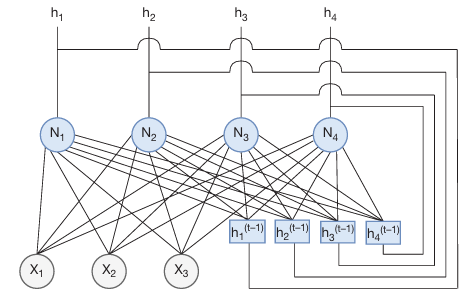 *Exemplo de uma arquitetura de uma RNN simples*

A figura acima mostra um vetor de entrada de três valores conectado a uma camada totalmente conectada de quatro neurônios. Os valores de *bias* foram omitidos da figura. Juntamente com as três entradas (e a entrada de *bias*), cada neurônio tem quatro entradas adicionais. Essas entradas recebem os valores de saída dos quatro neurônios, mas com um **atraso de um passo de tempo (timestep)**. Ou seja, no tempo t, ele receberá o valor de saída do tempo t-1. Denotamos essas saídas como h de hidden (oculto), porque as camadas recorrentes tipicamente servem como camadas ocultas dentro da rede.

O número de entradas para um neurônio em uma camada de RNN depende tanto do número de entradas para a camada (tipicamente determinado pelo número de neurônios na camada anterior) quanto do número de neurônios na própria camada.

## **REPRESENTAÇÃO MATEMÁTICA DE UMA CAMADA RECORRENTE**

Podemos representar uma camada recorrente usando matrizes. A forma como fica a representação lembra muito a representação matemática de uma camada *fully connected*. No entanto, o vetor de entrada para uma camada recorrente pode ser dividido em dois, o vetor de entrada real **Xt** e o vetor da saída anterior **Ht-1**. Da mesma forma, a matriz de pesos pode ser dividida em duas, uma para os pesos das entradas reais e outra para as conexões recorrentes. A fórmula pode ser representada como:

 *O b representa o vetor dos biases que são somados as somas ponderadas de cada um dos neurônios.*

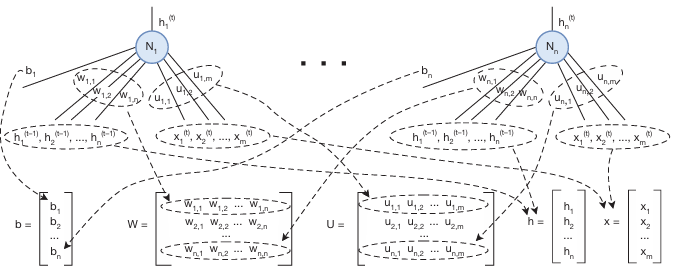 *Representação visual de como os elementos nas matrizes e vetores se mapeiam para entradas, conexçoes recorrentes, pesos e biases em uma camada recorrente.*

## **COMBINANDO CAMADAS EM UMA RNN**

Tentando criar uma rede para resolver o problema de previsão de vendas, montei uma arquitetura inicial básica para isso.

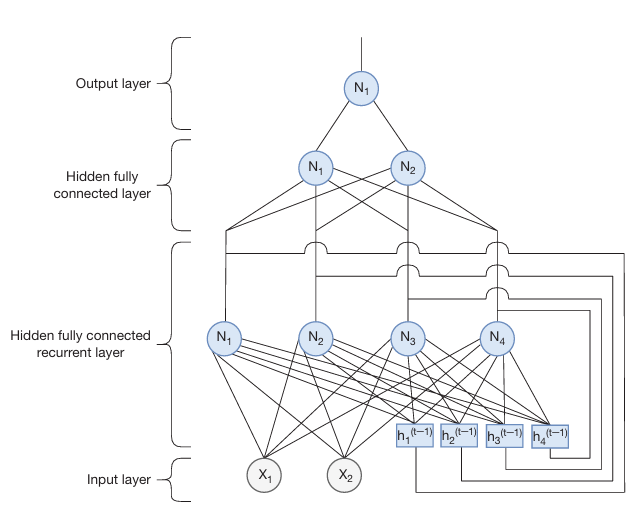 *Arquitetura montada para a previsão de vendas.*

Essa rede inicial possui duas entradas, representando as vendas históricas de livros e os gastos gerais do consumidor. Essas entradas alimentam uma camada recorrente com 4 neurônios, seguida por uma camada *fully connected* de 2 neurônios e uma camada de saída com um único neurônio. Com relação à funções de ativação, como queremos que a saída seja um valor numérico qualquer e não uma probabilidade, para a camada de saída usarei uma unidade linear simples. Para as *hidden layers*, posso escolher qualquer função de ativação não linear para camadas ocultas que comentei nos materiais passados.

O cálculo da saída desta rede é feito iterativamente, apresentando primeiro o vetor de entrada de um mês à rede e computando os estados ocultos, e depois apresentando o vetor de entrada do mês seguinte e computando novos estados ocultos, que são funções dos estados ocultos atuais e do novo vetor de entrada. Fazendo isso para todos os dados históricos a que tenho acesso e termino com uma previsão para o próximo mês. A rede pode usar todos esses dados e computar qualquer representação interna útil dos dados históricos que possa usar para prever o próximo mês. 

## **REPRESENTAÇÃO MAIS SIMPLES DA ARQUITETURA DE UMA RNN**

Até agora, desenhamos explicitamente todas as conexões em nossa *RNN*, o que não é prático à medida que avançamos para redes mais profundas com muitas unidades em cada camada. Para contornar essa limitação, uma maneira mais compacta de desenhar redes é deixar que um nó no grafo represente uma camada inteira, como na figura abaixo.

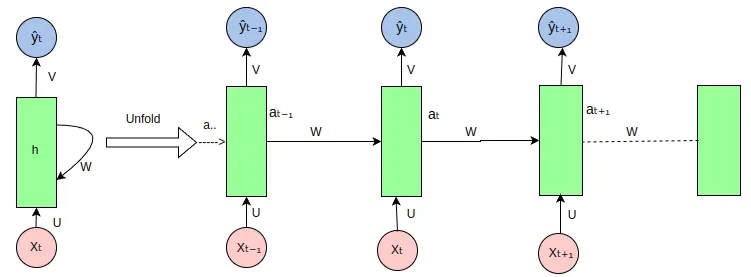 *Representação de uma RNN*

O retângulo representa a camada inteira e o círculo, neurônios individuais. Essas setas representam as conexões recorrentes. Com esta notação, muitas informações sobre a arquitetura ficam implícitas, então a figura precisa ser acompanhada por descrições textuais que deixem claro que ela é totalmente conectada, bem como o número de neurônios.

O lado direito da imagem mostra como fica uma camada recorrente **"desenrolada no tempo" (*unrolled intime*)**. Ao criar uma cópia da camada recorrente para cada passo de tempo, convertemos a camada recorrente em uma série de camadas *feedforward*. Isso significa que a camada recorrente é equivalente à rede *feedforward* se soubermos o comprimento da sequência de entrada? Não exatamente, porque uma distinção fundamental é descoberta se considerarmos os pesos da rede, que foram omitidos de todas as figuras. Na rede *feedforward*, podemos ter pesos diferentes para todas as conexões, mas na camada recorrente, os pesos precisam ser os mesmos para cada passo de tempo, por isso a representação desses pesos na imagem acima tem somente a letra **W** repetindo em todos os pesos de recorrência, a letra **U** repetindo como peso de entrada e a letra **V** repetindo como peso de saída. Ou seja, assim como as camadas convolucionais têm compartilhamento de pesos dentro de uma camada, as camadas recorrentes são como uma rede *feedforward* com compartilhamento de pesos entre camadas. Assim como o compartilhamento de pesos foi benéfico para as redes convolucionais, as redes recorrentes têm um benefício similar de exigir menos pesos para treinar.

Além de ajudar a compreender melhor a rede, essa representação ajuda a entender como o algoritmo de *backpropagation* funciona para essa rede.

## **BACKPROPAGATION NA RNN**

Uma vez que a rede é desenrolada, podemos retropropagar o erro exatamente da mesma forma que fazemos para uma rede feedforward, embora possa ser um tanto computacionalmente caro em casos com sequências de entrada longas. Assim como na camada convolucional, devemos garantir que o compartilhamento de pesos seja levado em conta ao atualizar os pesos.